# NB08 - Aprendizaje sensible al costo y clases desbalanceadas

**Objetivos de aprendizaje**

- Crear un escenario artificialmente desbalanceado con Iris binario.
- Mostrar por qué accuracy puede ser enganoso.
- Aplicar ponderación de clases y pesos manuales.
- Ajustar umbrales bajo costos asimétricos.
- Usar SMOTE y comparar estrategias con métricas precisión-recall.

**Referencias de este notebook**

- Elkan (2001): fundamenta el aprendizaje sensible al costo y el cambio de umbral óptimo.
- Chawla et al. (2002): introducen SMOTE para sobremuestreo sintético.
- He & Garcia (2009): revisan desbalance, muestreo y métricas adecuadas.


In [1]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Los notebooks pueden ejecutarse desde la raiz del repo o desde notebooks/.
# Este bloque localiza la raiz y agrega src/ al path de importacion.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils import (
    COLOR_PALETTE,
    RANDOM_STATE,
    get_train_test_split,
    load_binary_iris,
    load_processed_splits,
    plot_coefficients,
    plot_decision_boundary,
    plot_regularization_path,
    plot_sigmoid,
    save_processed_splits,
    set_plot_style,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
set_plot_style()
np.random.seed(RANDOM_STATE)

DATA_DIR = PROJECT_ROOT / "data" / "processed"

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)


## 1. Desbalance artificial

Conservamos todas las `virginica` de entrenamiento y solo una fracción de `versicolor`. La convención global sigue igual: `virginica=1`, `versicolor=0`. En este notebook la clase minoritaria será `versicolor`.

**Parámetros del desbalance.** Conservamos todas las `virginica` y cerca de 15% de las `versicolor`, con un mínimo de 4 ejemplos minoritarios. Esto crea un caso pequeño pero suficientemente extremo para que accuracy pueda engañar sin destruir por completo la posibilidad de aprendizaje.


In [2]:
# Creamos un desbalance artificial reproducible a partir del split compartido de entrenamiento.
data = load_processed_splits(DATA_DIR)
X_train = data["X_train"]
X_test = data["X_test"]
X_train_scaled = data["X_train_scaled"]
X_test_scaled = data["X_test_scaled"]
y_train = data["y_train"]
y_test = data["y_test"]
feature_names = data["feature_names"]

rng = np.random.default_rng(RANDOM_STATE)
idx_majority = y_train[y_train == 1].index.to_numpy()
idx_minority = y_train[y_train == 0].index.to_numpy()
# 15% simula una minoría severa; max(4, ...) evita que SMOTE y las métricas queden sin soporte.
keep_minority = rng.choice(idx_minority, size=max(4, int(0.15 * len(idx_minority))), replace=False)
keep_idx = np.sort(np.r_[idx_majority, keep_minority])

X_train_imb = X_train.loc[keep_idx].reset_index(drop=True)
X_train_imb_scaled = X_train_scaled.loc[keep_idx].reset_index(drop=True)
y_train_imb = y_train.loc[keep_idx].reset_index(drop=True)

ratio_table = y_train_imb.value_counts().rename(index={0: "versicolor (minoritaria)", 1: "virginica"}).to_frame("conteo")
ratio_table["proporcion"] = ratio_table["conteo"] / ratio_table["conteo"].sum()
display(ratio_table.round(3))


,conteo,proporcion
virginica,,
virginica,35,0.875
versicolor (minoritaria),5,0.125


**Interpretación.** Creamos un train donde `versicolor` es rara. Evaluaremos sobre el test original para ver cómo una decisión entrenada con datos sesgados afecta la recuperación de la minoría.


## 2. Modelo ingenuo y problema del accuracy

**Baseline y umbral.** El modelo base usa `C=1.0`, `solver='lbfgs'` y `max_iter=5000`, igual que NB03, para que el único cambio sea el desbalance del entrenamiento. La función `minority_metrics` usa `threshold=0.5` por defecto: cualquier cambio posterior en recall de la minoría se puede atribuir a pesos, umbral o SMOTE.


In [3]:
def minority_metrics(name, y_true, prob_virginica, threshold=0.5):
    # Para favorecer o medir la clase minoritaria (versicolor=0),
    # usamos probabilidad de minoritaria = 1 - P(virginica).
    pred = (prob_virginica >= threshold).astype(int)
    prob_minority = 1 - prob_virginica
    return {
        "modelo": name,
        "threshold_virginica": threshold,
        "accuracy": accuracy_score(y_true, pred),
        "precision_minoria": precision_score(y_true, pred, pos_label=0, zero_division=0),
        "recall_minoria": recall_score(y_true, pred, pos_label=0, zero_division=0),
        "f1_minoria": f1_score(y_true, pred, pos_label=0, zero_division=0),
        "PR_AUC_minoria": average_precision_score((y_true == 0).astype(int), prob_minority),
    }


# C=1.0 y lbfgs replican el baseline L2 moderado; max_iter=5000 solo asegura convergencia.
base_model = LogisticRegression(C=1.0, solver="lbfgs", max_iter=5000, random_state=RANDOM_STATE)
base_model.fit(X_train_imb_scaled, y_train_imb)
base_prob = base_model.predict_proba(X_test_scaled)[:, 1]

results = [minority_metrics("Base desbalanceado", y_test, base_prob)]
display(pd.DataFrame(results).round(4))


,modelo,threshold_virginica,accuracy,precision_minoria,recall_minoria,f1_minoria,PR_AUC_minoria
0,Base desbalanceado,0.5,0.8333,0.9167,0.7333,0.8148,0.9471


**Interpretación.** He & Garcia (2009) advierten que accuracy puede ocultar mal rendimiento en la clase rara. Por eso medimos recall, F1 y PR AUC de la minoría, no solo aciertos totales.


## 3. Solución 1: ponderación de clases

**Pesos de clase.** `class_weight='balanced'` calcula pesos inversamente proporcionales a la frecuencia observada. El diccionario `{0: 6.0, 1: 1.0}` fuerza manualmente que un error sobre `versicolor` cueste seis veces más que uno sobre `virginica`; es un ejemplo pedagógico de costo asimétrico, no un valor universal.


In [4]:
# class_weight="balanced" calcula pesos inversos a la frecuencia de cada clase en train desbalanceado.
# C=1.0, lbfgs y max_iter=5000 se mantienen fijos para aislar el efecto de los pesos.
weighted_balanced = LogisticRegression(
    C=1.0,
    solver="lbfgs",
    class_weight="balanced",
    max_iter=5000,
    random_state=RANDOM_STATE,
)
weighted_balanced.fit(X_train_imb_scaled, y_train_imb)
balanced_prob = weighted_balanced.predict_proba(X_test_scaled)[:, 1]
results.append(minority_metrics("class_weight='balanced'", y_test, balanced_prob))

# Peso 6:1 hace seis veces más costoso equivocarse en versicolor=0 que en virginica=1.
manual_weights = {0: 6.0, 1: 1.0}
weighted_manual = LogisticRegression(
    C=1.0,
    solver="lbfgs",
    class_weight=manual_weights,
    max_iter=5000,
    random_state=RANDOM_STATE,
)
weighted_manual.fit(X_train_imb_scaled, y_train_imb)
manual_prob = weighted_manual.predict_proba(X_test_scaled)[:, 1]
results.append(minority_metrics("pesos manuales {0:6,1:1}", y_test, manual_prob))

display(pd.DataFrame(results).round(4))


,modelo,threshold_virginica,accuracy,precision_minoria,recall_minoria,f1_minoria,PR_AUC_minoria
0,Base desbalanceado,0.5,0.8333,0.9167,0.7333,0.8148,0.9471
1,class_weight='balanced',0.5,0.8333,0.8125,0.8667,0.8387,0.9471
2,"pesos manuales {0:6,1:1}",0.5,0.8667,0.8667,0.8667,0.8667,0.9471


**Interpretación.** La ponderación aumenta el costo de equivocarse en la clase minoritaria. Es una forma directa de aprendizaje sensible al costo, coherente con la perspectiva de Elkan (2001).


## 4. Solución 2: ajuste de umbral

**Umbral ajustado.** `adjusted_threshold=0.70` significa que exigimos 70% de probabilidad para declarar `virginica=1`; por lo tanto, más casos dudosos se quedan como `versicolor=0`. Es una decisión operacional para proteger la minoría, no un hiperparámetro aprendido automáticamente.


In [5]:
# Como la minoría es versicolor=0, subir el umbral para declarar virginica
# desplaza casos dudosos hacia versicolor y busca mayor recall de la minoría.
adjusted_threshold = 0.70
results.append(minority_metrics("base con umbral ajustado", y_test, base_prob, threshold=adjusted_threshold))
display(pd.DataFrame(results).round(4))


,modelo,threshold_virginica,accuracy,precision_minoria,recall_minoria,f1_minoria,PR_AUC_minoria
0,Base desbalanceado,0.5,0.8333,0.9167,0.7333,0.8148,0.9471
1,class_weight='balanced',0.5,0.8333,0.8125,0.8667,0.8387,0.9471
2,"pesos manuales {0:6,1:1}",0.5,0.8667,0.8667,0.8667,0.8667,0.9471
3,base con umbral ajustado,0.7,0.8667,0.8667,0.8667,0.8667,0.9471


**Interpretación.** Elkan (2001) muestra que el umbral óptimo no tiene por qué ser 0.5: depende de costos y tasas base. Subir el umbral de `virginica` protege más a la clase `versicolor`.


## 5. Solución 3: SMOTE

**Parámetros de SMOTE.** `k_neighbors=max(1, min(3, minority_count-1))` adapta el número de vecinos al pequeño conteo minoritario: SMOTE no puede pedir más vecinos que ejemplos disponibles. El modelo posterior vuelve a usar `C=1.0`, `solver='lbfgs'` y `max_iter=5000` para que la diferencia venga del remuestreo, no de cambiar el clasificador.


In [6]:
# SMOTE crea observaciones sintéticas de la minoría interpolando entre vecinos.
# k_neighbors se acota por minority_count para que el algoritmo sea válido con muy pocos puntos.
minority_count = int((y_train_imb == 0).sum())
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=max(1, min(3, minority_count - 1)))
X_smote_scaled, y_smote = smote.fit_resample(X_train_imb_scaled, y_train_imb)

# Mantenemos el mismo clasificador base; así aislamos el efecto de SMOTE.
smote_model = LogisticRegression(C=1.0, solver="lbfgs", max_iter=5000, random_state=RANDOM_STATE)
smote_model.fit(X_smote_scaled, y_smote)
smote_prob = smote_model.predict_proba(X_test_scaled)[:, 1]
results.append(minority_metrics("SMOTE + logística", y_test, smote_prob))

display(pd.Series(y_smote).value_counts().rename(index={0: "versicolor", 1: "virginica"}).to_frame("conteo_post_SMOTE"))
display(pd.DataFrame(results).round(4))


  File "C:\Users\memom\AppData\Local\Temp\uv-lr-ortografia-cache\archive-v0\jy4pwmE5f2-koPYDhgbyV\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,conteo_post_SMOTE
virginica,
virginica,35
versicolor,35


,modelo,threshold_virginica,accuracy,precision_minoria,recall_minoria,f1_minoria,PR_AUC_minoria
0,Base desbalanceado,0.5,0.8333,0.9167,0.7333,0.8148,0.9471
1,class_weight='balanced',0.5,0.8333,0.8125,0.8667,0.8387,0.9471
2,"pesos manuales {0:6,1:1}",0.5,0.8667,0.8667,0.8667,0.8667,0.9471
3,base con umbral ajustado,0.7,0.8667,0.8667,0.8667,0.8667,0.9471
4,SMOTE + logística,0.5,0.8667,0.8667,0.8667,0.8667,0.9515


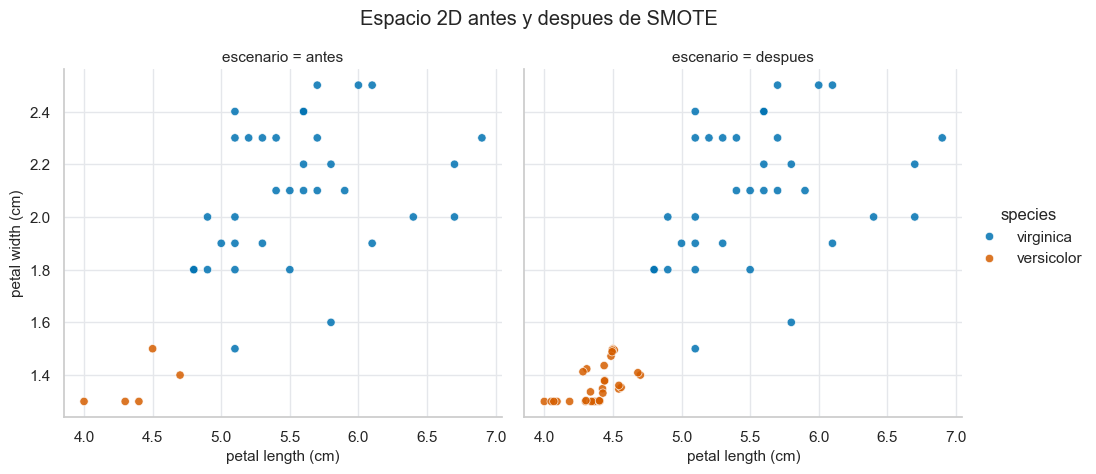

In [7]:
# Para visualizar SMOTE en unidades originales usamos solo dos features.
features_2d = ["petal length (cm)", "petal width (cm)"]
X_2d_imb = X_train_imb[features_2d].reset_index(drop=True)
# Repetimos el mismo criterio de k_neighbors para que la visualización 2D sea comparable.
smote_2d = SMOTE(random_state=RANDOM_STATE, k_neighbors=max(1, min(3, minority_count - 1)))
X_2d_smote, y_2d_smote = smote_2d.fit_resample(X_2d_imb, y_train_imb)

before = X_2d_imb.copy()
before["species"] = y_train_imb.map({0: "versicolor", 1: "virginica"})
before["escenario"] = "antes"

after = pd.DataFrame(X_2d_smote, columns=features_2d)
after["species"] = pd.Series(y_2d_smote).map({0: "versicolor", 1: "virginica"})
after["escenario"] = "despues"

plot_df = pd.concat([before, after], ignore_index=True)
grid = sns.relplot(
    data=plot_df,
    x=features_2d[0],
    y=features_2d[1],
    hue="species",
    col="escenario",
    kind="scatter",
    height=4.5,
    aspect=1.1,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5,
)
grid.fig.suptitle("Espacio 2D antes y despues de SMOTE", y=1.05)
plt.show()


**Interpretación.** Chawla et al. (2002) propusieron SMOTE para sintetizar ejemplos de la minoría entre vecinos cercanos. El gráfico muestra que no duplica puntos: rellena regiones plausibles del espacio de features.


## 6. Comparación con curvas PR


,modelo,threshold_virginica,accuracy,precision_minoria,recall_minoria,f1_minoria,PR_AUC_minoria
0,Base desbalanceado,0.5,0.8333,0.9167,0.7333,0.8148,0.9471
1,class_weight='balanced',0.5,0.8333,0.8125,0.8667,0.8387,0.9471
2,"pesos manuales {0:6,1:1}",0.5,0.8667,0.8667,0.8667,0.8667,0.9471
3,base con umbral ajustado,0.7,0.8667,0.8667,0.8667,0.8667,0.9471
4,SMOTE + logística,0.5,0.8667,0.8667,0.8667,0.8667,0.9515


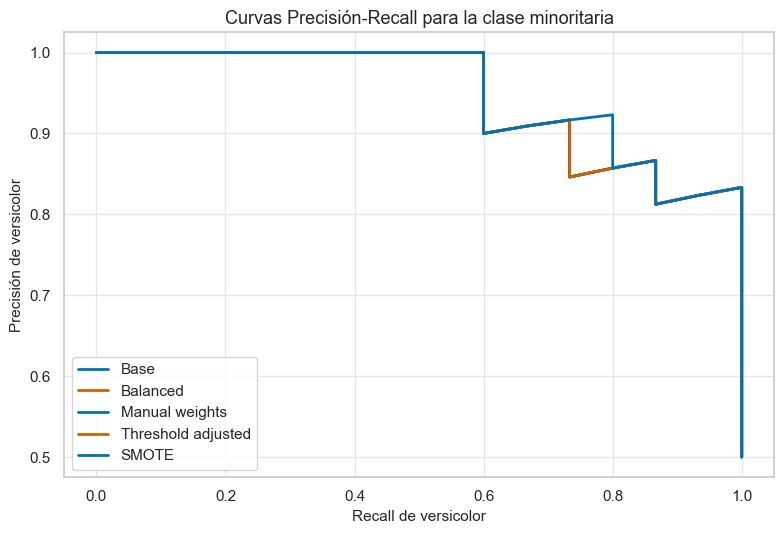

In [8]:
# Comparamos las curvas PR desde la perspectiva de la clase minoritaria.
results_df = pd.DataFrame(results)
display(results_df.round(4))

probas = {
    "Base": base_prob,
    "Balanced": balanced_prob,
    "Manual weights": manual_prob,
    "Threshold adjusted": base_prob,
    "SMOTE": smote_prob,
}

fig, ax = plt.subplots(figsize=(8, 5.5))
for name, prob in probas.items():
    prob_minority = 1 - prob
    precision, recall, _ = precision_recall_curve((y_test == 0).astype(int), prob_minority)
    ax.plot(recall, precision, linewidth=2, label=name)
ax.set_title("Curvas Precisión-Recall para la clase minoritaria")
ax.set_xlabel("Recall de versicolor")
ax.set_ylabel("Precisión de versicolor")
ax.legend()
fig.tight_layout()
plt.show()


**Interpretación.** Las estrategias mueven la curva o el punto operativo de formas distintas. Pesos de clase cambian el entrenamiento; umbral cambia la decisión; SMOTE cambia la distribución de entrenamiento. La elección depende de costos, datos disponibles y necesidad de interpretabilidad.


## Resumen y conexion con la literatura

Elkan (2001) explica por qué los costos asimétricos alteran el umbral óptimo y justifican pesos de clase. Chawla et al. (2002) introducen SMOTE, que aquí usamos para crear ejemplos sintéticos de `versicolor`. He & Garcia (2009) conectan el problema de desbalance con la necesidad de mirar precisión-recall, recall de minoría y métricas menos vulnerables que accuracy.
